# ARTI406 – Assignment 2
## Data Preprocessing and Dimensionality Reduction

Dataset used in this notebook: **Iris Dataset (from sklearn)**

This notebook covers:
1. Identifying data quality issues
2. Handling missing values
3. Detecting outliers using IQR
4. Normalizing numerical features (Min‑Max and Z‑Score)
5. Applying PCA and interpreting explained variance

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

# Load Dataset

In [4]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


# Task 1 – Identify Data Quality Issues

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [6]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [7]:
df.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

### Explanation

The dataset is mostly clean. However, in real-world datasets we often find:
- Missing values
- Duplicate rows
- Outliers
- Incorrect data types

To demonstrate preprocessing techniques, we will artificially introduce missing values.

# Task 2 – Handle Missing Values

In [8]:
# introduce missing values
df_missing = df.copy()
df_missing.iloc[0:10,0] = np.nan

df_missing.isna().sum()

sepal length (cm)    10
sepal width (cm)      0
petal length (cm)     0
petal width (cm)      0
species               0
dtype: int64

In [9]:
# Mean Imputation
df_missing.fillna(df_missing.mean(numeric_only=True), inplace=True)

df_missing.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

### Explanation
Mean imputation replaces missing values with the average value of the column. This method keeps the dataset size unchanged and is suitable for numerical data.

# Task 3 – Detect and Handle Outliers Using IQR

In [10]:
Q1 = df['sepal length (cm)'].quantile(0.25)
Q3 = df['sepal length (cm)'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['sepal length (cm)'] < lower_bound) | (df['sepal length (cm)'] > upper_bound)]

print('Outliers found:', len(outliers))

Outliers found: 0


In [11]:
Q1 = df['sepal length (cm)'].quantile(0.25)
Q3 = df['sepal length (cm)'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['sepal length (cm)'] < lower_bound) | (df['sepal length (cm)'] > upper_bound)]

print('Outliers found:', len(outliers))

Outliers found: 0


# Task 4 – Normalize Numerical Features

## Min-Max Scaling

In [12]:
minmax = MinMaxScaler()

df_minmax = df.copy()
df_minmax[df.columns[:-1]] = minmax.fit_transform(df_minmax[df.columns[:-1]])

df_minmax.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,0.222222,0.625000,0.067797,0.041667,0
1,0.166667,0.416667,0.067797,0.041667,0
2,0.111111,0.500000,0.050847,0.041667,0
3,0.083333,0.458333,0.084746,0.041667,0
4,0.194444,0.666667,0.067797,0.041667,0


## Z‑Score Standardization

In [13]:
scaler = StandardScaler()

df_z = df.copy()
df_z[df.columns[:-1]] = scaler.fit_transform(df_z[df.columns[:-1]])

df_z.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,-0.900681,1.019004,-1.340227,-1.315444,0
1,-1.143017,-0.131979,-1.340227,-1.315444,0
2,-1.385353,0.328414,-1.397064,-1.315444,0
3,-1.506521,0.098217,-1.283389,-1.315444,0
4,-1.021849,1.249201,-1.340227,-1.315444,0


# Task 5 – PCA and Explained Variance

In [14]:
features = df.iloc[:,:4]

scaler = StandardScaler()
scaled = scaler.fit_transform(features)

pca = PCA()
pca_data = pca.fit_transform(scaled)

explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

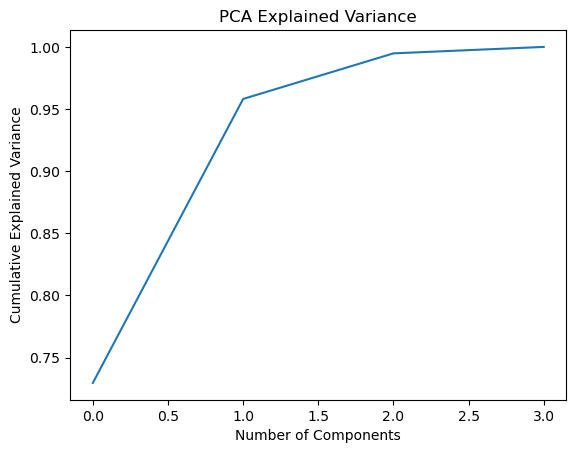

In [15]:
plt.plot(np.cumsum(explained_variance))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

### Interpretation

The explained variance ratio indicates how much information each principal component captures.
If the first few components explain most of the variance, the dataset can be reduced to fewer dimensions
while preserving most of the information.